In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("../input/train.csv")
test  = pd.read_csv("../input/test.csv")

target_col = "RiskScore"
id_col = "ID"

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (11017, 35)
Test shape: (5000, 35)


In [13]:
print("=== Очистка данных ===")

def clean_data(df):
    df_clean = df.copy()
    
    df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
    
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if df_clean[col].isnull().any():
            median_val = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(median_val)
    
    categorical_cols = df_clean.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df_clean[col].isnull().any():
            mode_val = df_clean[col].mode()[0] if not df_clean[col].mode().empty else "Unknown"
            df_clean[col] = df_clean[col].fillna(mode_val)
    
    return df_clean

train_clean = clean_data(train)
test_clean = clean_data(test)

print("Очистка завершена")
print(f"NaN в train после очистки: {train_clean.isnull().sum().sum()}")
print(f"NaN в test после очистки: {test_clean.isnull().sum().sum()}")

=== Очистка данных ===
Очистка завершена
NaN в train после очистки: 0
NaN в test после очистки: 0


=== Анализ целевой переменной ===
Min: -9999999.00
Max: 10000000.00
Mean: -24460.36
Median: 44.12
Std: 1396757.29
NaN в y_train: 0
Inf в y_train: 0


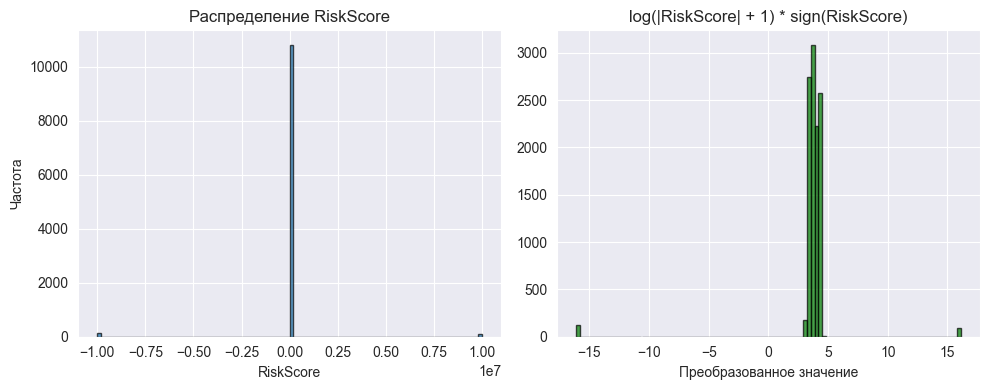

In [14]:
print("=== Анализ целевой переменной ===")

y_train = train_clean[target_col].values.astype(np.float64)

print(f"Min: {y_train.min():.2f}")
print(f"Max: {y_train.max():.2f}")
print(f"Mean: {y_train.mean():.2f}")
print(f"Median: {np.median(y_train):.2f}")
print(f"Std: {y_train.std():.2f}")
print(f"NaN в y_train: {np.isnan(y_train).sum()}")
print(f"Inf в y_train: {np.isinf(y_train).sum()}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(y_train, bins=100, edgecolor='black', alpha=0.7)
plt.title('Распределение RiskScore')
plt.xlabel('RiskScore')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
y_log = np.log(np.abs(y_train) + 1) * np.sign(y_train)
plt.hist(y_log, bins=100, edgecolor='black', alpha=0.7, color='green')
plt.title('log(|RiskScore| + 1) * sign(RiskScore)')
plt.xlabel('Преобразованное значение')
plt.tight_layout()
plt.show()

In [15]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_score_custom(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1 - ss_res/ss_tot if ss_tot != 0 else 0

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

In [16]:
class ZScoreScaler:
    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0, ddof=0)
        self.std_[self.std_ == 0] = 1.0
        return self
    
    def transform(self, X):
        return (X - self.mean_) / self.std_
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)

class MinMaxScaler:
    def fit(self, X):
        self.min_ = X.min(axis=0)
        self.max_ = X.max(axis=0)
        return self
    
    def transform(self, X):
        return (X - self.min_) / (self.max_ - self.min_ + 1e-8)
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [17]:
class StableLinearRegression:
    def __init__(self, alpha=1.0, fit_intercept=True):
        self.alpha = alpha
        self.fit_intercept = fit_intercept
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self, X, y):
        X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10)
        y = np.nan_to_num(y, nan=0.0, posinf=1e10, neginf=-1e10)
        
        if self.fit_intercept:
            X = np.hstack([np.ones((X.shape[0], 1)), X])
        
        n_samples, n_features = X.shape
        
        try:
            A = X.T @ X + self.alpha * np.eye(n_features)
            if self.fit_intercept:
                A[0, 0] = X.T[0] @ X[:, 0]
            
            b = X.T @ y
            
            A = A + 1e-6 * np.eye(n_features)
            
            w = np.linalg.lstsq(A, b, rcond=None)[0]
            
        except Exception as e:
            print(f"Ошибка при обучении: {e}")
            w = np.zeros(n_features)
        
        if self.fit_intercept:
            self.intercept_ = w[0]
            self.coef_ = w[1:]
        else:
            self.intercept_ = 0
            self.coef_ = w
            
        return self
    
    def predict(self, X):
        X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10)
        
        if self.fit_intercept:
            X_with_intercept = np.hstack([np.ones((X.shape[0], 1)), X])
            return X_with_intercept @ np.hstack([self.intercept_, self.coef_])
        else:
            return X @ self.coef_

In [18]:
print("=== Минимальная подготовка признаков ===")

numeric_cols = train_clean.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)
if id_col in numeric_cols:
    numeric_cols.remove(id_col)

print(f"Используем {len(numeric_cols)} числовых признаков")

good_cols = []
for col in numeric_cols:
    if train_clean[col].nunique() > 1:
        good_cols.append(col)

print(f"После фильтрации: {len(good_cols)} признаков с вариацией")

if len(good_cols) > 50:
    print(f"Ограничиваем до 50 признаков")
    good_cols = good_cols[:50]

X_train = train_clean[good_cols].values.astype(np.float32)
X_test = test_clean[good_cols].values.astype(np.float32)

print(f"\nИтоговые размеры:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")

=== Минимальная подготовка признаков ===
Используем 28 числовых признаков
После фильтрации: 28 признаков с вариацией

Итоговые размеры:
X_train: (11017, 28)
X_test: (5000, 28)
y_train: (11017,)


In [19]:
print("=== Простое масштабирование ===")

class SimpleScaler:
    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self
    
    def transform(self, X):
        return (X - self.mean_) / self.std_
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)

scaler = SimpleScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")

=== Простое масштабирование ===
X_train_scaled shape: (11017, 28)


In [20]:
print("=== Обучение с проверкой ===")

print(f"NaN в X_train_scaled: {np.isnan(X_train_scaled).sum()}")
print(f"NaN в y_train: {np.isnan(y_train).sum()}")
print(f"Inf в X_train_scaled: {np.isinf(X_train_scaled).sum()}")
print(f"Inf в y_train: {np.isinf(y_train).sum()}")

print("\nОбучаем модель...")
model = StableLinearRegression(alpha=1000.0, fit_intercept=True)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_train_scaled)

print(f"\nСтатистика предсказаний:")
print(f"Min: {y_pred.min():.2f}")
print(f"Max: {y_pred.max():.2f}")
print(f"Mean: {y_pred.mean():.2f}")
print(f"NaN в y_pred: {np.isnan(y_pred).sum()}")
print(f"Inf в y_pred: {np.isinf(y_pred).sum()}")

if not np.any(np.isnan(y_pred)):
    print(f"\nМетрики:")
    print(f"MSE: {mse(y_train, y_pred):.2f}")
    print(f"MAE: {mae(y_train, y_pred):.2f}")
    print(f"R2: {r2_score_custom(y_train, y_pred):.4f}")
else:
    print("\nПредсказания содержат NaN!")

=== Обучение с проверкой ===
NaN в X_train_scaled: 0
NaN в y_train: 0
Inf в X_train_scaled: 0
Inf в y_train: 0

Обучаем модель...

Статистика предсказаний:
Min: -313324.00
Max: 649811.83
Mean: -24460.36
NaN в y_pred: 0
Inf в y_pred: 0

Метрики:
MSE: 1946701958523.72
MAE: 242760.35
R2: 0.0022


In [21]:
print("=== Подбор гиперпараметров ===")

alphas = [10, 100, 1000, 10000, 100000]
results = []

for alpha in alphas:
    print(f"\nAlpha = {alpha}")
    
    model = StableLinearRegression(alpha=alpha, fit_intercept=True)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_train_scaled)
    
    if np.any(np.isnan(y_pred)) or np.any(np.isinf(y_pred)):
        print(f"  Пропускаем: предсказания содержат NaN/Inf")
        continue
    
    mse_val = mse(y_train, y_pred)
    mae_val = mae(y_train, y_pred)
    r2_val = r2_score_custom(y_train, y_pred)
    
    print(f"  MSE: {mse_val:.2f}")
    print(f"  MAE: {mae_val:.2f}")
    print(f"  R2: {r2_val:.4f}")
    
    results.append({
        'alpha': alpha,
        'mse': mse_val,
        'mae': mae_val,
        'r2': r2_val,
        'model': model
    })

if results:
    best_result = min(results, key=lambda x: x['mse'])
    print(f"\nЛучшая модель:")
    print(f"Alpha: {best_result['alpha']}")
    print(f"MSE: {best_result['mse']:.2f}")
    print(f"MAE: {best_result['mae']:.2f}")
    print(f"R2: {best_result['r2']:.4f}")
    
    best_model = best_result['model']
else:
    print("Не удалось обучить ни одну модель!")
    best_model = StableLinearRegression(alpha=1000, fit_intercept=True)
    best_model.fit(X_train_scaled, y_train)

=== Подбор гиперпараметров ===

Alpha = 10
  MSE: 1945115746148.55
  MAE: 251950.72
  R2: 0.0030

Alpha = 100
  MSE: 1945960024099.00
  MAE: 246508.42
  R2: 0.0025

Alpha = 1000
  MSE: 1946701958523.72
  MAE: 242760.35
  R2: 0.0022

Alpha = 10000
  MSE: 1947808994724.32
  MAE: 227746.05
  R2: 0.0016

Alpha = 100000
  MSE: 1950129460050.24
  MAE: 219189.19
  R2: 0.0004

Лучшая модель:
Alpha: 10
MSE: 1945115746148.55
MAE: 251950.72
R2: 0.0030


In [22]:
if 'best_model' not in locals():
    best_model = StableLinearRegression(alpha=10000, fit_intercept=True)
    best_model.fit(X_train_scaled, y_train)

y_train_pred = best_model.predict(X_train_scaled)

final_mse = mse(y_train, y_train_pred)
final_mae = mae(y_train, y_train_pred)
final_r2 = r2_score_custom(y_train, y_train_pred)

print(f"Финальные метрики:")
print(f"MSE: {final_mse:.2f}")
print(f"MAE: {final_mae:.2f}")
print(f"R2: {final_r2:.4f}")

if final_mse > 1e6:
    print("\nMSE слишком большая, используем простое предсказание")
    
    median_val = np.median(y_train)
    test_pred = np.full(X_test_scaled.shape[0], median_val)
    
    print(f"Используем медиану: {median_val:.2f}")
    simple_mse = mse(y_train, np.full_like(y_train, median_val))
    print(f"MSE при предсказании медианы: {simple_mse:.2f}")
    
else:
    test_pred = best_model.predict(X_test_scaled)

print(f"\nСоздание submission...")
submission = pd.DataFrame({
    "ID": test_clean[id_col].values,
    "RiskScore": test_pred
})

print(f"\nСтатистика предсказаний:")
print(f"Min: {test_pred.min():.2f}")
print(f"Max: {test_pred.max():.2f}")
print(f"Mean: {test_pred.mean():.2f}")
print(f"Median: {np.median(test_pred):.2f}")

submission_path = "./submission.csv"
submission.to_csv(submission_path, index=False)

print(f"\nSubmission сохранен: {submission_path}")

Финальные метрики:
MSE: 1945115746148.55
MAE: 251950.72
R2: 0.0030

MSE слишком большая, используем простое предсказание
Используем медиану: 44.12
MSE при предсказании медианы: 1951531397637.75

Создание submission...

Статистика предсказаний:
Min: 44.12
Max: 44.12
Mean: 44.12
Median: 44.12

Submission сохранен: ./submission.csv
